<a href="https://colab.research.google.com/github/VooDooPR/father/blob/main/tenser_flow_pr2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import kagglehub
import tensorflow as tf
import os

# датасет
path = kagglehub.dataset_download("alessiocorrado99/animals10")

# путь к изображениям
data_dir = os.path.join(path, "raw-img")

# параметры
IMG_SIZE = (96, 96)
BATCH_SIZE = 64
SEED = 42

# загрузка датасета
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# классы
class_names = train_ds.class_names
num_classes = len(class_names)

print("Классы:", class_names)
print("Количество классов:", num_classes)

Using Colab cache for faster access to the 'animals10' dataset.
Found 26179 files belonging to 10 classes.
Using 20944 files for training.
Found 26179 files belonging to 10 classes.
Using 5235 files for validation.
Классы: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
Количество классов: 10


In [20]:
#предобаротка
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

AUTOTUNE = tf.data.AUTOTUNE
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# оптимизация pipeline
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Предобработка данных завершена")

Предобработка данных завершена



На данном этапе была выполнена загрузка и предварительная обработка датасета Animals-10.
Датасет содержит 10 классов цветных RGB-изображений животных.
Изображения были приведены к единому размеру 128×128 пикселей, а значения пикселей нормализованы к диапазону [0, 1].


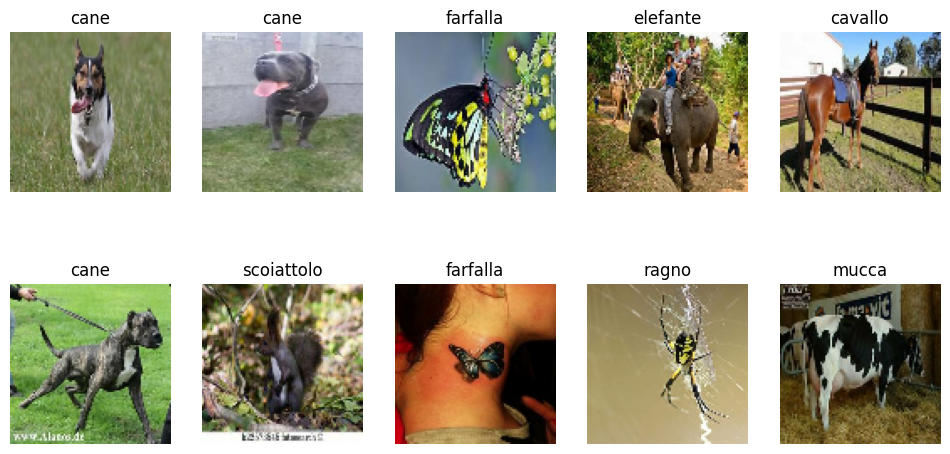

In [21]:
#визуал

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for images, labels in train_ds.take(1):
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

plt.show()

In [24]:
#проектирование
model_1 = models.Sequential([
    layers.Input(shape=(96, 96, 3)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation='softmax')
])

model_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,453,962 (9.36 MB)

 Trainable params: 2,453,962 (9.36 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
#обучение дефолтной модели
start_time = time.time()

history_1 = model_1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1
)

end_time = time.time()

train_time_1 = end_time - start_time
print(f"Обучение базовой модели завершено за {train_time_1:.2f} секунд")

Epoch 1/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 517s 2s/step - accuracy: 0.3394 - loss: 1.8652 - val_accuracy: 0.4883 - val_loss: 1.4924
Epoch 2/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 559s 2s/step - accuracy: 0.4986 - loss: 1.4489 - val_accuracy: 0.5534 - val_loss: 1.3129
Epoch 3/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 557s 2s/step - accuracy: 0.5733 - loss: 1.2529 - val_accuracy: 0.6222 - val_loss: 1.1338
Epoch 4/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 504s 2s/step - accuracy: 0.6261 - loss: 1.0922 - val_accuracy: 0.6508 - val_loss: 1.0532
Epoch 5/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 503s 2s/step - accuracy: 0.6595 - loss: 0.9788 - val_accuracy: 0.6691 - val_loss: 1.0077
Epoch 6/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 505s 2s/step - accuracy: 0.7026 - loss: 0.8610 - val_accuracy: 0.6913 - val_loss: 0.9432
Epoch 7/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 560s 2s/step - accuracy: 0.7333 - loss: 0.7631 - val_accuracy: 0.6835 - val_loss: 0.9714
Epoch 8/10
328/328 ━━━━━━━━━━━━━━━━━━━━ 564s 2s/step - accuracy: 0.7667 - loss: 0.6688 - val_accu

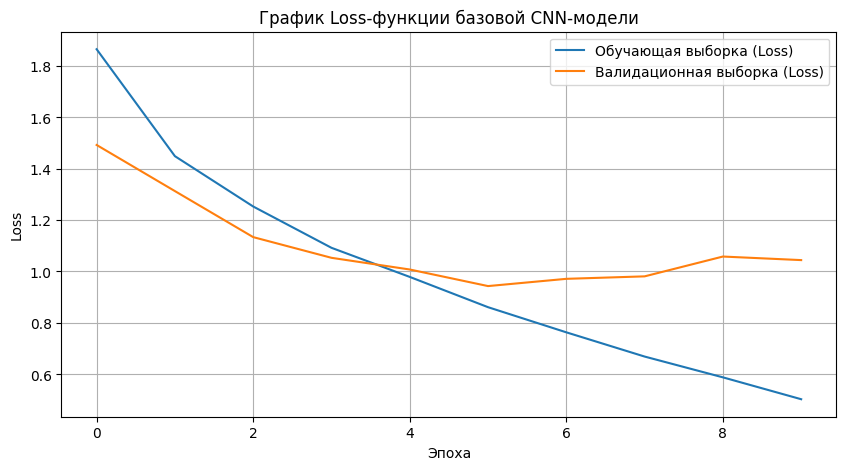

In [26]:
#accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history_1.history['loss'], label='Обучающая выборка (Loss)')
plt.plot(history_1.history['val_loss'], label='Валидационная выборка (Loss)')
plt.title('График Loss-функции базовой CNN-модели')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

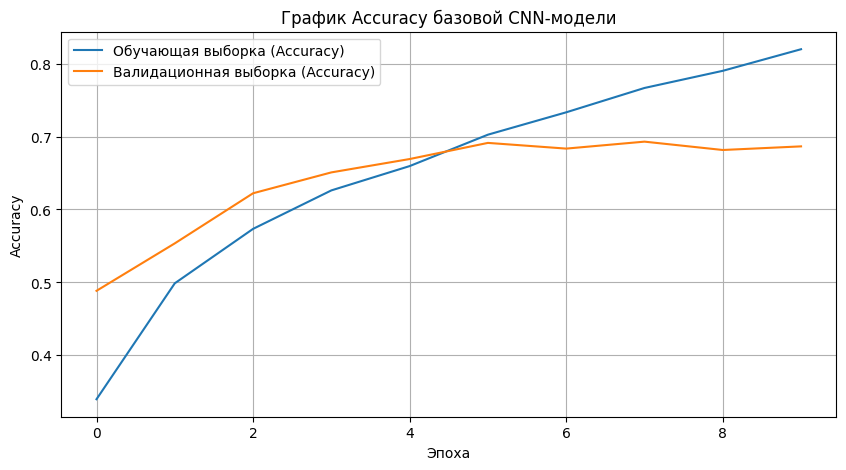

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(history_1.history['accuracy'], label='Обучающая выборка (Accuracy)')
plt.plot(history_1.history['val_accuracy'], label='Валидационная выборка (Accuracy)')
plt.title('График Accuracy базовой CNN-модели')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
#оценка полученной модели
y_true_1 = []
y_pred_1 = []

start_inference = time.time()

for images, labels in val_ds:
    preds = model_1.predict(images, verbose=0)
    y_true_1.extend(labels.numpy())
    y_pred_1.extend(np.argmax(preds, axis=1))

end_inference = time.time()

inference_time_1 = end_inference - start_inference
fps_1 = len(y_true_1) / inference_time_1

accuracy_1 = accuracy_score(y_true_1, y_pred_1)
precision_1 = precision_score(y_true_1, y_pred_1, average='weighted')
recall_1 = recall_score(y_true_1, y_pred_1, average='weighted')
f1_1 = f1_score(y_true_1, y_pred_1, average='weighted')

print("Метрики базовой CNN-модели:")
print(f"--- Accuracy: {accuracy_1:.4f}")
print(f"--- Precision: {precision_1:.4f}")
print(f"--- Recall: {recall_1:.4f}")
print(f"--- F1-score: {f1_1:.4f}")
print(f"--- FPS: {fps_1:.2f} изображений/сек")

print("\nПодробный отчет по классам:")
print(classification_report(y_true_1, y_pred_1, target_names=class_names))

Метрики базовой CNN-модели:
--- Accuracy: 0.6865
--- Precision: 0.6943
--- Recall: 0.6865
--- F1-score: 0.6861
--- FPS: 91.77 изображений/сек

Подробный отчет по классам:
              precision    recall  f1-score   support

        cane       0.62      0.75      0.68       956
     cavallo       0.74      0.63      0.68       534
    elefante       0.64      0.59      0.62       256
    farfalla       0.80      0.72      0.76       406
     gallina       0.78      0.79      0.79       641
       gatto       0.52      0.31      0.39       303
       mucca       0.51      0.59      0.55       364
      pecora       0.54      0.58      0.56       363
       ragno       0.88      0.79      0.83      1025
  scoiattolo       0.56      0.66      0.61       387

    accuracy                           0.69      5235
   macro avg       0.66      0.64      0.65      5235
weighted avg       0.69      0.69      0.69      5235



In [29]:
#оптимизация модели
model_2 = models.Sequential([
    layers.Input(shape=(96, 96, 3)),

    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(96, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation='softmax')
])

model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 96, 96, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 24, 24, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 12, 12, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 96)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,642 (318.91 KB)

 Trainable params: 81,642 (318.91 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
from tensorflow.keras.callbacks import EarlyStopping

# улучшение модели
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
start_time = time.time()
history_2 = model_2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop],
    verbose=1
)
end_time = time.time()
train_time_2 = end_time - start_time
print(f"Обучение оптимизированной модели завершено за {train_time_2:.2f} секунд")

Epoch 1/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 509s 2s/step - accuracy: 0.1948 - loss: 2.1938 - val_accuracy: 0.2176 - val_loss: 2.1453
Epoch 2/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 567s 2s/step - accuracy: 0.2479 - loss: 2.0817 - val_accuracy: 0.1291 - val_loss: 2.3636
Epoch 3/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 570s 2s/step - accuracy: 0.2796 - loss: 1.9979 - val_accuracy: 0.2191 - val_loss: 2.1505
Epoch 4/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 519s 2s/step - accuracy: 0.3132 - loss: 1.9258 - val_accuracy: 0.2753 - val_loss: 2.0258
Epoch 5/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 562s 2s/step - accuracy: 0.3481 - loss: 1.8437 - val_accuracy: 0.2651 - val_loss: 2.2110
Epoch 6/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 510s 2s/step - accuracy: 0.3761 - loss: 1.7829 - val_accuracy: 0.2695 - val_loss: 2.2903
Epoch 7/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 517s 2s/step - accuracy: 0.3979 - loss: 1.7284 - val_accuracy: 0.3108 - val_loss: 2.0890
Epoch 8/15
328/328 ━━━━━━━━━━━━━━━━━━━━ 509s 2s/step - accuracy: 0.4097 - loss: 1.6901 - val_accu

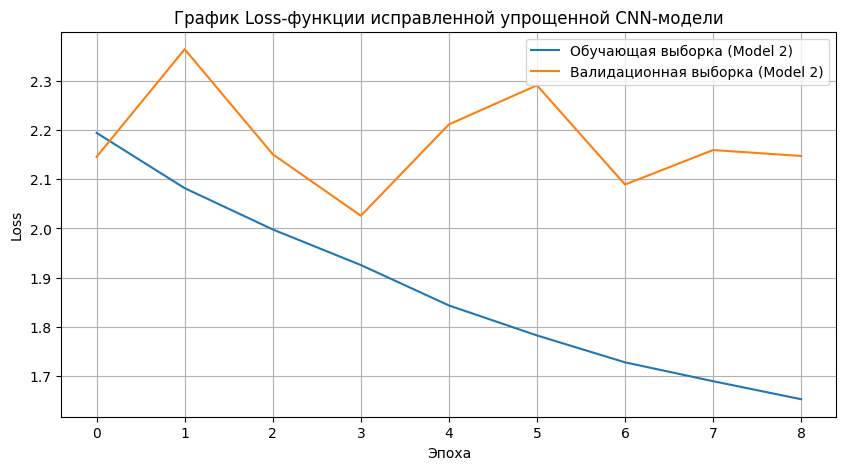

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(history_2.history['loss'], label='Обучающая выборка (Model 2)')
plt.plot(history_2.history['val_loss'], label='Валидационная выборка (Model 2)')
plt.title('График Loss-функции исправленной упрощенной CNN-модели')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

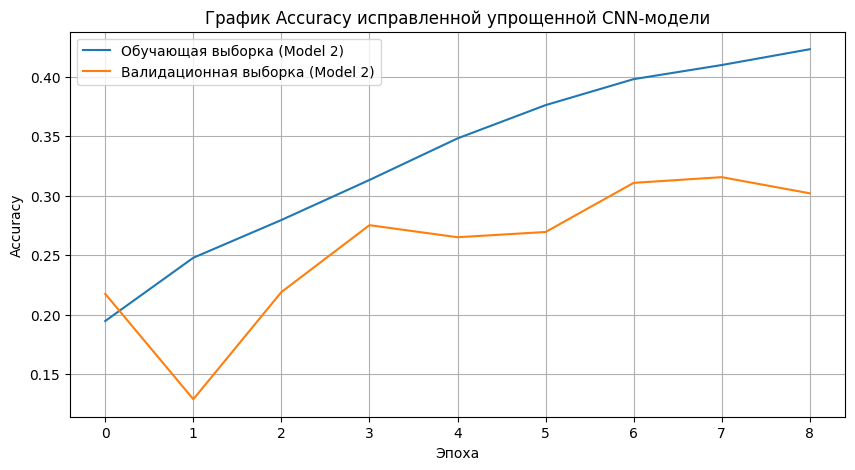

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(history_2.history['accuracy'], label='Обучающая выборка (Model 2)')
plt.plot(history_2.history['val_accuracy'], label='Валидационная выборка (Model 2)')
plt.title('График Accuracy исправленной упрощенной CNN-модели')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [34]:
y_true_2 = []
y_pred_2 = []

start_inference = time.time()

for images, labels in val_ds:
    preds = model_2.predict(images, verbose=0)
    y_true_2.extend(labels.numpy())
    y_pred_2.extend(np.argmax(preds, axis=1))

end_inference = time.time()

inference_time_2 = end_inference - start_inference
fps_2 = len(y_true_2) / inference_time_2

accuracy_2 = accuracy_score(y_true_2, y_pred_2)
precision_2 = precision_score(y_true_2, y_pred_2, average='weighted', zero_division=0)
recall_2 = recall_score(y_true_2, y_pred_2, average='weighted', zero_division=0)
f1_2 = f1_score(y_true_2, y_pred_2, average='weighted', zero_division=0)

print("Метрики исправленной упрощенной CNN-модели:")
print(f"--- Accuracy: {accuracy_2:.4f}")
print(f"--- Precision: {precision_2:.4f}")
print(f"--- Recall: {recall_2:.4f}")
print(f"--- F1-score: {f1_2:.4f}")
print(f"--- FPS: {fps_2:.2f} изображений/сек")

print("\nПодробный отчет по классам:")
print(classification_report(
    y_true_2,
    y_pred_2,
    target_names=class_names,
    zero_division=0
))

Метрики исправленной упрощенной CNN-модели:
--- Accuracy: 0.2753
--- Precision: 0.2964
--- Recall: 0.2753
--- F1-score: 0.2222
--- FPS: 100.28 изображений/сек

Подробный отчет по классам:
              precision    recall  f1-score   support

        cane       0.41      0.17      0.24       956
     cavallo       0.23      0.37      0.28       534
    elefante       0.00      0.00      0.00       256
    farfalla       0.17      0.86      0.28       406
     gallina       0.25      0.14      0.18       641
       gatto       0.00      0.00      0.00       303
       mucca       0.35      0.06      0.10       364
      pecora       0.67      0.01      0.01       363
       ragno       0.43      0.60      0.50      1025
  scoiattolo       0.00      0.00      0.00       387

    accuracy                           0.28      5235
   macro avg       0.25      0.22      0.16      5235
weighted avg       0.30      0.28      0.22      5235



In [35]:
comparison = pd.DataFrame({
    "Параметр": [
        "Архитектура",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "FPS",
        "Время обучения (сек)",
        "Количество параметров"
    ],
    "Модель №1 (Base CNN)": [
        "Conv32 → Conv64 → Conv128 → Dense128",
        round(accuracy_1, 4),
        round(precision_1, 4),
        round(recall_1, 4),
        round(f1_1, 4),
        round(fps_1, 2),
        round(train_time_1, 2),
        model_1.count_params()
    ],
    "Модель №2 (Optimized CNN)": [
        "Conv32 → Conv64 → Conv64 → Dense64",
        round(accuracy_2, 4),
        round(precision_2, 4),
        round(recall_2, 4),
        round(f1_2, 4),
        round(fps_2, 2),
        round(train_time_2, 2),
        model_2.count_params()
    ]
})

comparison

,Параметр,Модель №1 (Base CNN),Модель №2 (Optimized CNN)
0,Архитектура,Conv32 → Conv64 → Conv128 → Dense128,Conv32 → Conv64 → Conv64 → Dense64
1,Accuracy,0.6865,0.2753
2,Precision,0.6943,0.2964
3,Recall,0.6865,0.2753
4,F1-score,0.6861,0.2222
5,FPS,91.77,100.28
6,Время обучения (сек),5282.86,4825.46
7,Количество параметров,2453962,81642
